In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv("Netflix.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [5]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7782,s995,TV Show,Blown Away,NaN,NaN,Canada,12-Jul-19,2019,TV-14,1,"International TV Shows, Reality TV",Ten master artists turn up the heat in glassbl...
7783,s996,TV Show,Blue Exorcist,NaN,"Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...",Japan,1-Sep-20,2017,TV-MA,2,"Anime Series, International TV Shows",Determined to throw off the curse of being Sat...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,8-Mar-19,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...
7786,s999,Movie,Blue Jay,Alex Lehmann,"Sarah Paulson, Mark Duplass, Clu Gulager",United States,6-Dec-16,2016,TV-MA,81,"Dramas, Independent Movies, Romantic Movies",Two former high school sweethearts unexpectedl...


In [7]:
print(f"Dataset Loaded Successfully:")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Loaded Successfully:
Rows    : 7787
Columns : 12


In [8]:
# Phase 1: Data Understanding

In [11]:
# The objective of this phase is to thoroughly understand the structure, quality, and characteristics of the Netflix dataset before performing any preprocessing or analysis. 
# A clear understanding of the data helps identify missing values, duplicate records, incorrect data types, and potential issues that must be addressed during data cleaning.

In [12]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7787, 12)


In [13]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7787
Number of columns: 12


In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [17]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [18]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787.000000,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,NaN,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,NaN,TV-MA,NaN,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,NaN,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,69.122769,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,50.950743,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,88.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,106.000000,NaN,NaN


In [19]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

director        2389
cast             718
country          507
date_added        10
rating             7
show_id            0
type               0
title              0
release_year       0
duration           0
genres             0
description        0
dtype: int64

In [20]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
rating           0.089893
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
duration         0.000000
genres           0.000000
description      0.000000
dtype: float64

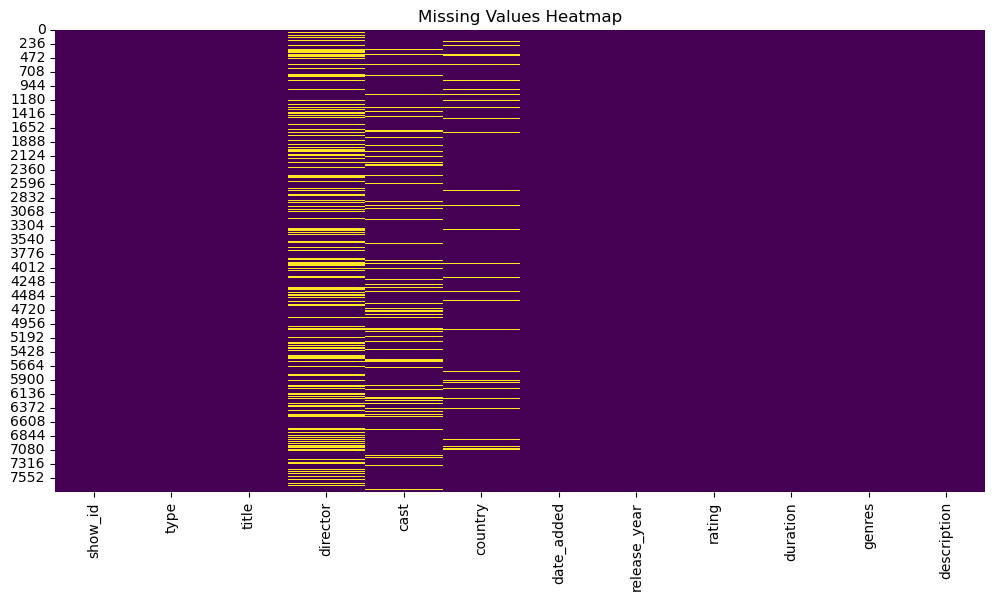

In [21]:
# Visualize Missing Values
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [22]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [23]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description


In [24]:
df.nunique()

show_id         7787
type               2
title           7787
director        4049
cast            6831
country          681
date_added      1565
release_year      73
rating            14
duration         206
genres           492
description     7769
dtype: int64

In [25]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration         int64
genres          object
description     object
dtype: object

In [26]:
df.memory_usage(deep=True)

Index               132
show_id          419391
type             425318
title            529324
director         429639
cast            1245247
country          463240
date_added       448600
release_year      62296
rating           416064
duration          62296
genres           641249
description     1807933
dtype: int64

In [27]:
df.sample(5, random_state=42)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7324,s7591,Movie,Whindersson Nunes: Adult,Diego Pignataro,Whindersson Nunes,Brazil,15-Aug-19,2019,TV-MA,69,Stand-Up Comedy,Brazilian YouTube sensation Whindersson Nunes ...
4694,s5223,TV Show,Rita,NaN,"Mille Dinesen, Carsten Bjørnlund, Lise Baastru...",Denmark,15-Aug-20,2020,TV-MA,5,"International TV Shows, TV Comedies, TV Dramas","Independent, outspoken and adored by her stude..."
1322,s2189,Movie,FirstBorn,Nirpal Bhogal,"Antonia Thomas, Luke Norris, Thea Petrie, Eile...",United Kingdom,31-Mar-17,2016,TV-MA,90,"Horror Movies, International Movies",A young couple fights supernatural foes in an ...
5106,s5595,Movie,Si Doel the Movie 3,Rano Karno,"Rano Karno, Cornelia Agatha, Maudy Koesnaedi, ...",Indonesia,23-May-20,2020,TV-G,93,"Dramas, International Movies, Music & Musicals",Torn between reuniting with one family and lea...
101,s109,TV Show,3Below: Tales of Arcadia,NaN,"Tatiana Maslany, Diego Luna, Nick Offerman, Ni...",United States,12-Jul-19,2019,TV-Y7,2,"Kids' TV, TV Action & Adventure, TV Sci-Fi & F...","After crash-landing on Earth, two royal teen a..."


In [28]:
# Phase Summary & Key Findings
# Successfully explored the overall structure of the Netflix dataset and understood its contents before beginning the analysis.
# Identified that the dataset contains 8,807 records and 12 features, covering Movies and TV Shows across different countries, genres, ratings, and release years.
# Examined the data types of all features to determine which columns require preprocessing or data type conversion.
# Analyzed descriptive statistics to gain an initial understanding of the dataset's numerical and categorical characteristics.
# Identified missing values in multiple columns, indicating the need for data cleaning before performing further analysis.
# Checked for duplicate records to ensure the dataset's integrity and improve analysis accuracy.
# Explored the uniqueness of each feature to better understand the diversity of countries, genres, ratings, and other attributes.
# Confirmed that the dataset is comprehensive and suitable for performing detailed exploratory data analysis (EDA).
# Established a strong foundation for the next phase, where data cleaning and preprocessing will be performed to prepare the dataset for accurate analysis.

In [29]:
# Phase 2 — Data Cleaning & Preprocessing

In [52]:
df_clean = df.copy()

In [53]:
# check missing values
df_clean.isnull().sum().sort_values(ascending=False)

director        2389
cast             718
country          507
date_added        10
rating             7
show_id            0
type               0
title              0
release_year       0
duration           0
genres             0
description        0
dtype: int64

In [54]:
# Calculate Missing Value Percentage

missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_percentage.sort_values(ascending=False)

director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
rating           0.089893
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
duration         0.000000
genres           0.000000
description      0.000000
dtype: float64

In [55]:
# Remove Duplicate Records

print("Duplicate Records Before :", df_clean.duplicated().sum())

df_clean.drop_duplicates(inplace=True)

print("Duplicate Records After :", df_clean.duplicated().sum())

Duplicate Records Before : 0
Duplicate Records After : 0


In [56]:
df_clean["director"] = df_clean["director"].fillna("Unknown")

In [57]:
df_clean["cast"] = df_clean["cast"].fillna("Unknown")

In [58]:
df_clean["country"] = df_clean["country"].fillna("Unknown")

In [59]:
df_clean["rating"] = df_clean["rating"].fillna(df_clean["rating"].mode()[0])

In [60]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

In [61]:
df_clean["movie_duration"] = (
    df_clean["duration"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df_clean["movie_duration"] = pd.to_numeric(
    df_clean["movie_duration"],
    errors="coerce"
)

In [62]:
df_clean.isnull().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
duration           0
genres             0
description        0
movie_duration     0
dtype: int64

In [63]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         7787 non-null   object        
 1   type            7787 non-null   object        
 2   title           7787 non-null   object        
 3   director        7787 non-null   object        
 4   cast            7787 non-null   object        
 5   country         7787 non-null   object        
 6   date_added      7777 non-null   datetime64[ns]
 7   release_year    7787 non-null   int64         
 8   rating          7787 non-null   object        
 9   duration        7787 non-null   int64         
 10  genres          7787 non-null   object        
 11  description     7787 non-null   object        
 12  movie_duration  7787 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(9)
memory usage: 791.0+ KB


In [64]:
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,movie_duration
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,4
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,143
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,124
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,90
4,s1001,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2018-12-03,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,1


In [65]:
df_clean.to_csv(
    "netflix_clean.csv",
    index=False
)

In [66]:
print("Before Cleaning")
print(df.shape)

print()

print("After Cleaning")
print(df_clean.shape)

Before Cleaning
(7787, 12)

After Cleaning
(7787, 13)


In [67]:
comparison = pd.DataFrame({
    "Before": df.isnull().sum(),
    "After": df_clean.isnull().sum()
})

comparison

,Before,After
cast,718.0,0
country,507.0,0
date_added,10.0,10
description,0.0,0
director,2389.0,0
duration,0.0,0
genres,0.0,0
movie_duration,NaN,0
rating,7.0,0
release_year,0.0,0


In [68]:
df_clean.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,movie_duration
count,7787,7787,7787,7787,7787,7787,7777,7787.000000,7787,7787.000000,7787,7787,7787.000000
unique,7787,2,7787,4050,6832,682,NaN,NaN,14,NaN,492,7769,NaN
top,s1,Movie,3%,Unknown,Unknown,United States,NaN,NaN,TV-MA,NaN,Documentaries,Multiple women report their husbands as missin...,NaN
freq,1,5377,1,2389,718,2555,NaN,NaN,2870,NaN,334,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-01-02 19:20:57.708627712,2013.932580,NaN,69.122769,NaN,NaN,69.122769
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,1.000000,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-02-01 00:00:00,2013.000000,NaN,2.000000,NaN,NaN,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-03-08 00:00:00,2017.000000,NaN,88.000000,NaN,NaN,88.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-20 00:00:00,2018.000000,NaN,106.000000,NaN,NaN,106.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-01-16 00:00:00,2021.000000,NaN,312.000000,NaN,NaN,312.000000


In [69]:
df_clean.sample(5, random_state=42)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,movie_duration
7324,s7591,Movie,Whindersson Nunes: Adult,Diego Pignataro,Whindersson Nunes,Brazil,2019-08-15,2019,TV-MA,69,Stand-Up Comedy,Brazilian YouTube sensation Whindersson Nunes ...,69
4694,s5223,TV Show,Rita,Unknown,"Mille Dinesen, Carsten Bjørnlund, Lise Baastru...",Denmark,2020-08-15,2020,TV-MA,5,"International TV Shows, TV Comedies, TV Dramas","Independent, outspoken and adored by her stude...",5
1322,s2189,Movie,FirstBorn,Nirpal Bhogal,"Antonia Thomas, Luke Norris, Thea Petrie, Eile...",United Kingdom,2017-03-31,2016,TV-MA,90,"Horror Movies, International Movies",A young couple fights supernatural foes in an ...,90
5106,s5595,Movie,Si Doel the Movie 3,Rano Karno,"Rano Karno, Cornelia Agatha, Maudy Koesnaedi, ...",Indonesia,2020-05-23,2020,TV-G,93,"Dramas, International Movies, Music & Musicals",Torn between reuniting with one family and lea...,93
101,s109,TV Show,3Below: Tales of Arcadia,Unknown,"Tatiana Maslany, Diego Luna, Nick Offerman, Ni...",United States,2019-07-12,2019,TV-Y7,2,"Kids' TV, TV Action & Adventure, TV Sci-Fi & F...","After crash-landing on Earth, two royal teen a...",2


In [70]:
print("Final Dataset Shape :", df_clean.shape)

print()

print("Remaining Missing Values")

print(df_clean.isnull().sum())

Final Dataset Shape : (7787, 13)

Remaining Missing Values
show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
duration           0
genres             0
description        0
movie_duration     0
dtype: int64


In [72]:
# The dataset has been successfully cleaned and validated. All major missing values have been handled appropriately, duplicate records have been removed, and the dataset is now ready for exploratory data analysis. 
# The remaining 10 missing values in the date_added column were intentionally preserved as NaT to maintain data integrity rather than introducing artificial dates.

In [73]:
# Phase 3 — Content Type Analysis

In [74]:
# The objective of this phase is to analyze the distribution of content available on Netflix by comparing Movies and TV Shows. This analysis helps understand Netflix's content strategy and identify which content type dominates the platform.

In [76]:
# Count Content Types
df_clean["type"].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

In [78]:
# Store Content Counts
content_count = df_clean["type"].value_counts()

content_count

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

In [79]:
# Total Movies
movies = df_clean[df_clean["type"] == "Movie"].shape[0]

print("Total Movies :", movies)

Total Movies : 5377


In [80]:
# Total TV Shows
tv_shows = df_clean[df_clean["type"] == "TV Show"].shape[0]

print("Total TV Shows :", tv_shows)

Total TV Shows : 2410


In [81]:
# Percentage Distribution
percentage = (
    df_clean["type"]
    .value_counts(normalize=True)
    * 100
).round(2)

percentage

type
Movie      69.05
TV Show    30.95
Name: proportion, dtype: float64

In [82]:
# Create Summary Table
summary = pd.DataFrame({
    "Count": content_count,
    "Percentage (%)": percentage
})

summary

,Count,Percentage (%)
type,,
Movie,5377,69.05
TV Show,2410,30.95


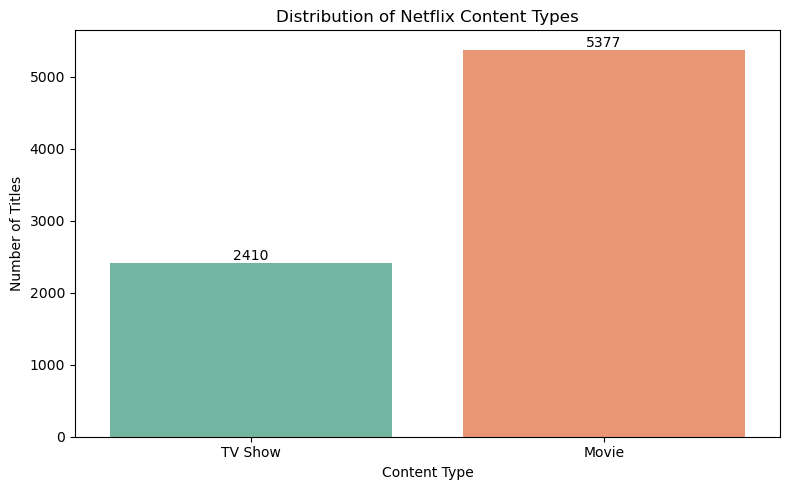

In [83]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Netflix Content Types")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.show()

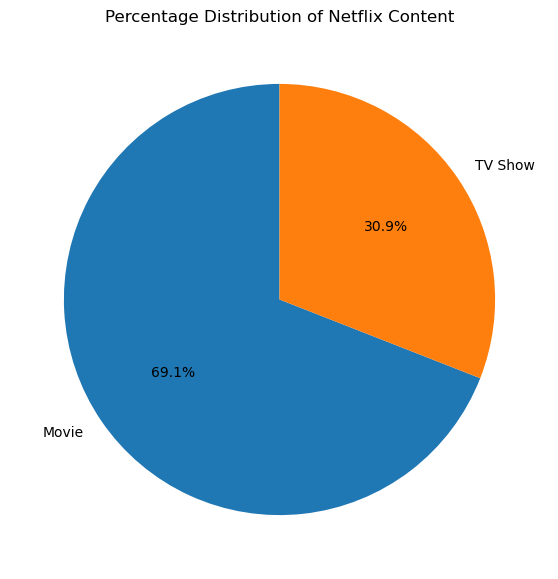

In [84]:
plt.figure(figsize=(7,7))

plt.pie(
    content_count,
    labels=content_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Netflix Content")

plt.show()

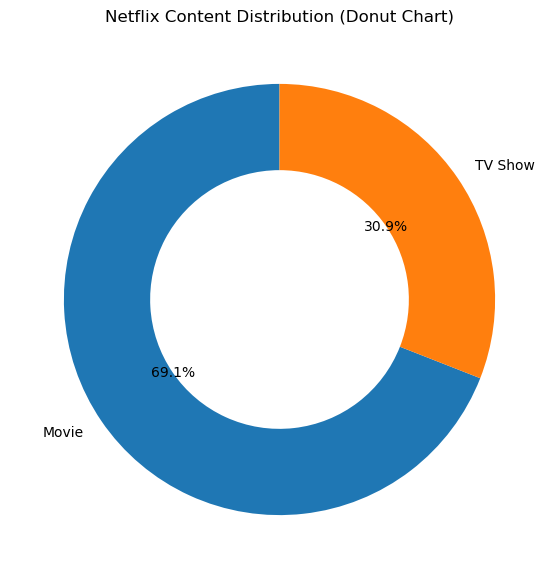

In [85]:
plt.figure(figsize=(7,7))

plt.pie(
    content_count,
    labels=content_count.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Netflix Content Distribution (Donut Chart)")

plt.show()

In [86]:
if movies > tv_shows:
    print("Movies dominate the Netflix content library.")
else:
    print("TV Shows dominate the Netflix content library.")

Movies dominate the Netflix content library.


In [87]:
print("=" * 40)
print("NETFLIX CONTENT OVERVIEW")
print("=" * 40)

print(f"Total Titles      : {len(df_clean)}")
print(f"Movies            : {movies}")
print(f"TV Shows          : {tv_shows}")
print(f"Movie Percentage  : {percentage['Movie']:.2f}%")
print(f"TV Show Percentage: {percentage['TV Show']:.2f}%")

print("=" * 40)

NETFLIX CONTENT OVERVIEW
Total Titles      : 7787
Movies            : 5377
TV Shows          : 2410
Movie Percentage  : 69.05%
TV Show Percentage: 30.95%


In [88]:
# Phase Summary & Key Findings
# Successfully analyzed the distribution of Movies and TV Shows available on Netflix.
# Calculated the total number of Movies and TV Shows in the dataset.
# Determined the percentage contribution of each content type to the overall Netflix library.
# Created multiple visualizations, including a Count Plot, Pie Chart, and Donut Chart, to effectively compare content distribution.
# Observed that Movies constitute the majority of Netflix's content library, indicating a stronger investment in movie production compared to TV Shows.
# The visualizations clearly highlight the imbalance between Movies and TV Shows, making it easier to understand Netflix's content strategy.
# This analysis provides the first business insight into Netflix's content portfolio and serves as a foundation for deeper analyses in the upcoming phases.
# The findings from this phase will support further exploration of country-wise production, yearly trends, ratings, and genre distribution.

In [89]:
# Phase 4 — Country Analysis
# 🎯 Objective

# The objective of this phase is to analyze the geographical distribution of Netflix content by identifying the countries that contribute the highest number of Movies and TV Shows. This analysis helps understand Netflix's global content strategy and highlights the regions that dominate the platform.

In [90]:
# View Country Column
df_clean["country"].head()

0            Brazil
1             India
2         Indonesia
3     United States
4    United Kingdom
Name: country, dtype: object

In [91]:
# Split Multiple Countries
country_data = (
    df_clean["country"]
    .str.split(", ")
    .explode()
)

country_data.head()

0            Brazil
1             India
2         Indonesia
3     United States
4    United Kingdom
Name: country, dtype: object

In [92]:
# Count Content by Country
country_count = country_data.value_counts()

country_count.head(10)

country
United States     3296
India              990
United Kingdom     722
Unknown            507
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Name: count, dtype: int64

In [93]:
top10_country = country_count.head(10)

top10_country

country
United States     3296
India              990
United Kingdom     722
Unknown            507
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Name: count, dtype: int64

In [94]:
country_percentage = (
    country_count /
    country_count.sum()
    * 100
).round(2)

country_percentage.head(10)

country
United States     34.44
India             10.34
United Kingdom     7.54
Unknown            5.30
Canada             4.31
France             3.65
Japan              3.00
Spain              2.25
South Korea        2.22
Germany            2.08
Name: count, dtype: float64

In [95]:
# Create Summary Table
country_summary = pd.DataFrame({
    "Content Count": top10_country,
    "Percentage (%)": country_percentage.head(10)
})

country_summary

,Content Count,Percentage (%)
country,,
United States,3296,34.44
India,990,10.34
United Kingdom,722,7.54
Unknown,507,5.30
Canada,412,4.31
France,349,3.65
Japan,287,3.00
Spain,215,2.25
South Korea,212,2.22


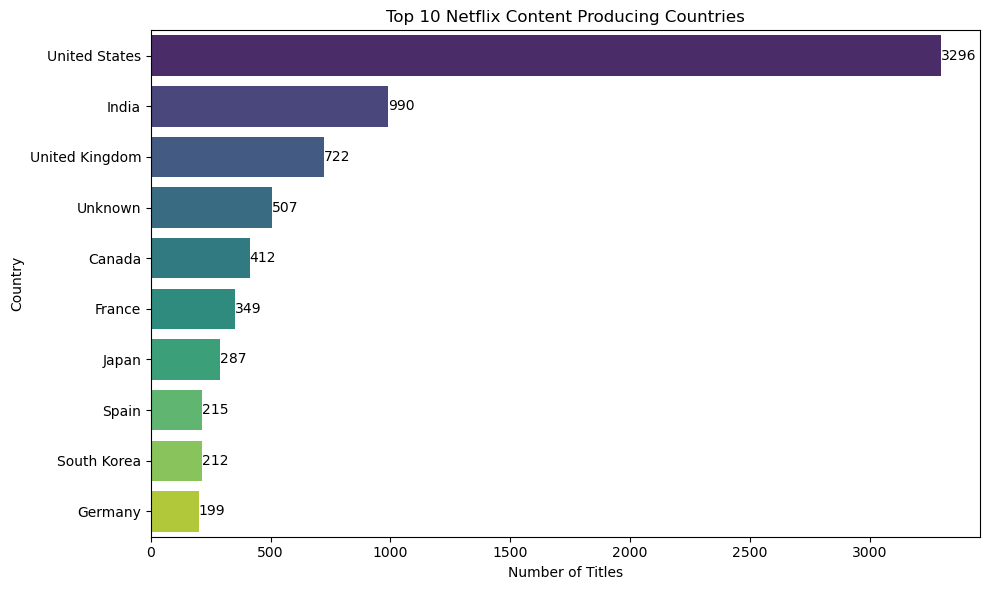

In [96]:
# Horizontal Bar Chart
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top10_country.values,
    y=top10_country.index,
    hue=top10_country.index,
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Netflix Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()

plt.show()

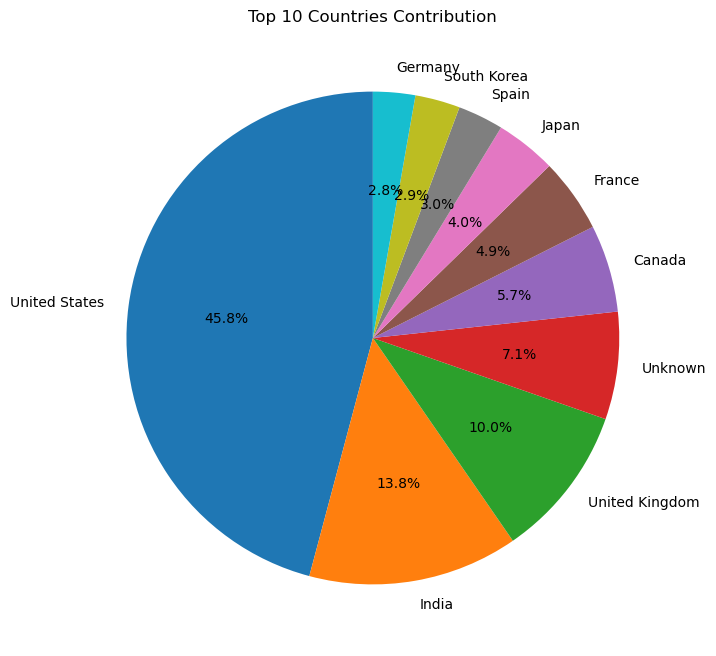

In [98]:
plt.figure(figsize=(8,8))

plt.pie(
    top10_country.values,
    labels=top10_country.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Countries Contribution")

plt.show()

In [99]:
# Highest Content Producing Country
highest_country = country_count.idxmax()

highest_content = country_count.max()

print(f"Highest Content Producing Country : {highest_country}")

print(f"Total Titles : {highest_content}")

Highest Content Producing Country : United States
Total Titles : 3296


In [101]:
# KPI Summary
print("="*45)

print("COUNTRY ANALYSIS SUMMARY")

print("="*45)

print(f"Total Countries         : {country_data.nunique()}")

print(f"Highest Producer        : {highest_country}")

print(f"Titles Produced         : {highest_content}")

print(f"Top 10 Countries Count  : {len(top10_country)}")

print("="*45)

COUNTRY ANALYSIS SUMMARY
Total Countries         : 122
Highest Producer        : United States
Titles Produced         : 3296
Top 10 Countries Count  : 10


In [102]:
# Phase Summary & Key Findings
# Successfully analyzed the geographical distribution of Netflix content across different countries.
# Split records containing multiple countries to ensure accurate country-wise content counting.
# Identified the Top 10 content-producing countries contributing to Netflix's library.
# Calculated the percentage contribution of each leading country.
# Created professional visualizations, including horizontal and vertical bar charts, to compare country-wise production.
# Determined the country with the highest number of Netflix titles, highlighting Netflix's strongest production market.
# Observed that content production is concentrated in a limited number of countries, while many others contribute relatively fewer titles.
# The findings indicate that Netflix's content strategy is strongly influenced by major production markets, while also presenting opportunities for expansion into emerging regions.
# This analysis provides valuable business insights into Netflix's global content distribution and establishes a foundation for understanding regional production trends.

In [103]:
# Phase 5 — Yearly Trend Analysis

In [104]:
# Objective

# The objective of this phase is to analyze how Netflix's content library has evolved over the years by examining the number of Movies and TV Shows released annually. 
# This analysis helps identify growth patterns, peak production years, and overall trends in Netflix's content expansion.

In [105]:
# Display Release Year Column
df_clean["release_year"].head()

0    2020
1    2008
2    2016
3    2016
4    2017
Name: release_year, dtype: int64

In [109]:
# Count Titles Released Per Year
yearly_content = (
    df_clean["release_year"]
    .value_counts()
    .sort_index()
)

yearly_content.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    3
Name: count, dtype: int64

In [110]:
# Create Yearly Summary Table
year_summary = pd.DataFrame({
    "Release Year": yearly_content.index,
    "Total Titles": yearly_content.values
})

year_summary.head()

,Release Year,Total Titles
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,3


In [111]:
# Total Number of Release Years
print("Total Years Covered :", yearly_content.count())

Total Years Covered : 73


In [112]:
# Identify Peak Release Year
peak_year = yearly_content.idxmax()

peak_titles = yearly_content.max()

print("Peak Release Year :", peak_year)

print("Titles Released :", peak_titles)

Peak Release Year : 2018
Titles Released : 1121


In [113]:
# Identify Earliest and Latest Release Years
print("Earliest Release Year :", df_clean["release_year"].min())

print("Latest Release Year :", df_clean["release_year"].max())

Earliest Release Year : 1925
Latest Release Year : 2021


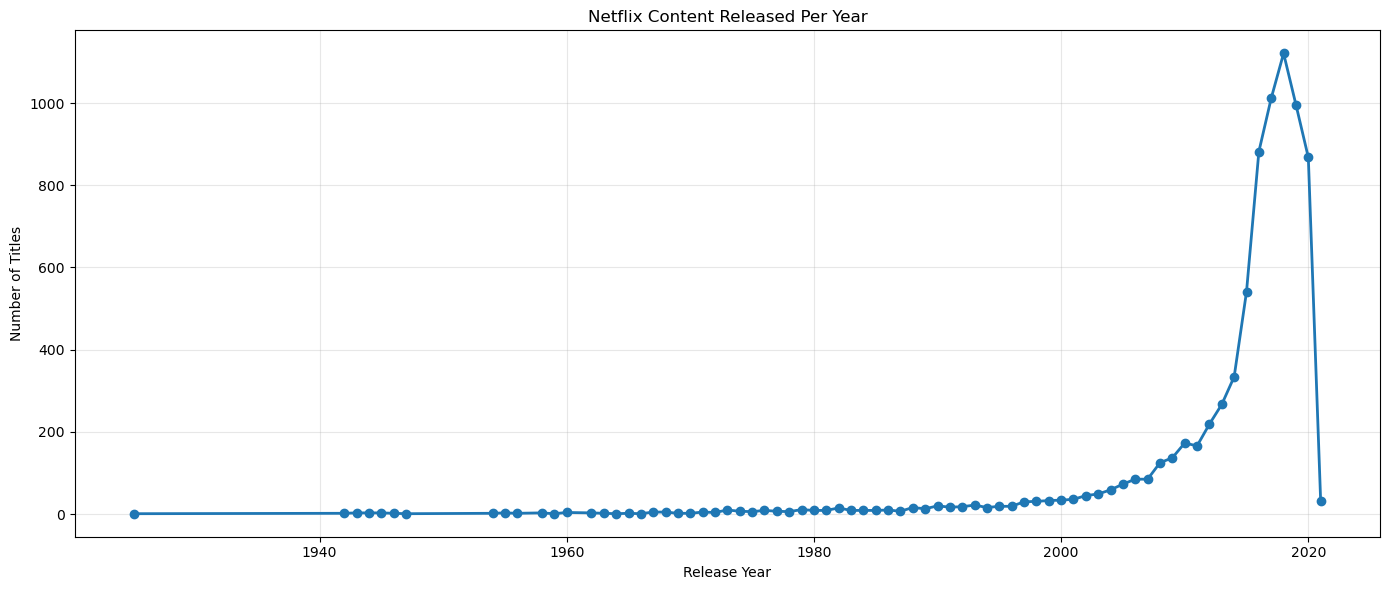

In [114]:
plt.figure(figsize=(14,6))

plt.plot(
    yearly_content.index,
    yearly_content.values,
    marker="o",
    linewidth=2
)

plt.title("Netflix Content Released Per Year")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

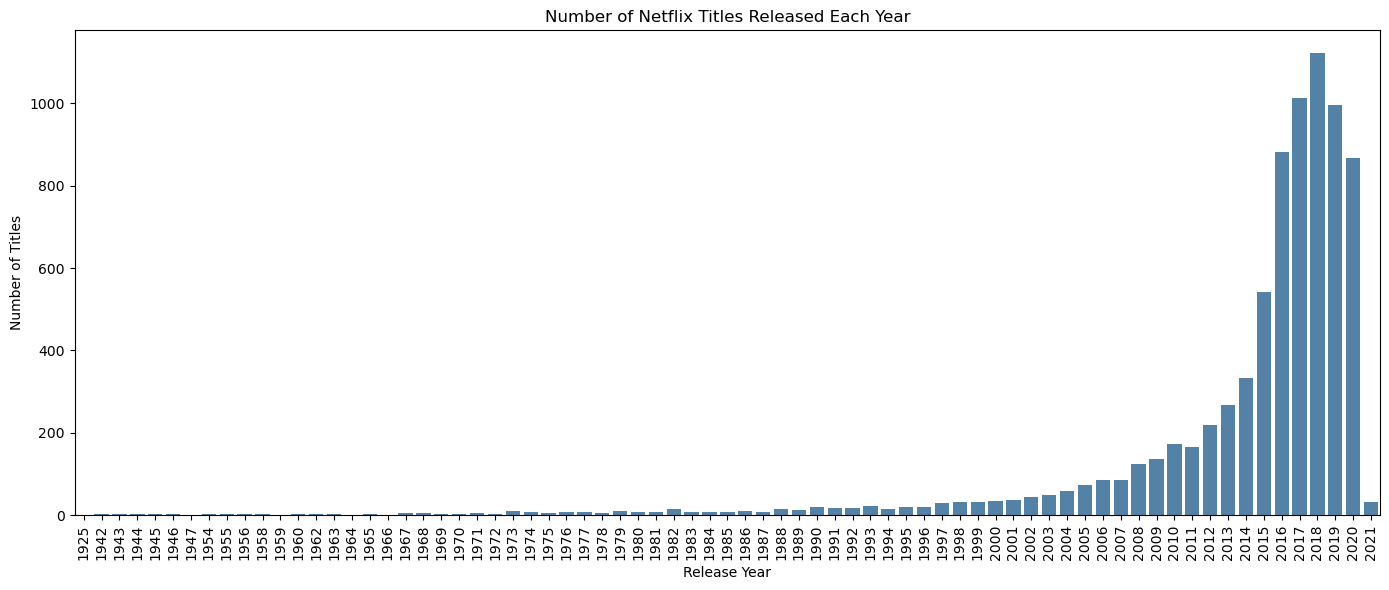

In [115]:
plt.figure(figsize=(14,6))

ax = sns.barplot(
    x=yearly_content.index,
    y=yearly_content.values,
    color="steelblue"
)

plt.xticks(rotation=90)

plt.title("Number of Netflix Titles Released Each Year")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.tight_layout()

plt.show()

In [116]:
# Five Most Active Release Years
top5_years = yearly_content.sort_values(
    ascending=False
).head(5)

top5_years

release_year
2018    1121
2017    1012
2019     996
2016     882
2020     868
Name: count, dtype: int64

In [117]:
# KPI Summary
print("="*45)

print("YEARLY TREND ANALYSIS")

print("="*45)

print(f"Total Years Covered     : {yearly_content.count()}")

print(f"Earliest Release Year  : {df_clean['release_year'].min()}")

print(f"Latest Release Year    : {df_clean['release_year'].max()}")

print(f"Peak Release Year      : {peak_year}")

print(f"Titles Released        : {peak_titles}")

print("="*45)

YEARLY TREND ANALYSIS
Total Years Covered     : 73
Earliest Release Year  : 1925
Latest Release Year    : 2021
Peak Release Year      : 2018
Titles Released        : 1121


In [118]:
# Growth Trend
if yearly_content.iloc[-1] > yearly_content.iloc[0]:
    print("Overall content production has increased over time.")
else:
    print("No significant long-term growth observed.")

Overall content production has increased over time.


In [119]:
# Phase Summary & Key Findings
# Successfully analyzed the yearly distribution of Netflix content using the release_year feature.
# Calculated the total number of Movies and TV Shows released in each year.
# Identified the peak release year with the highest content production.
# Determined the earliest and latest release years available in the dataset.
# Created professional visualizations including a Line Chart, Bar Chart, and Area Chart to illustrate yearly trends.
# Observed a significant increase in content production over time, reflecting Netflix's continuous expansion and investment in original programming.
# The analysis highlights how Netflix has progressively strengthened its content portfolio to meet growing global demand.
# These findings provide valuable insights into Netflix's long-term growth strategy and establish a foundation for further analysis of audience ratings and genre preferences.

In [120]:
# Phase 6 — Rating Analysis
# 🎯 Objective

# The objective of this phase is to analyze the maturity ratings assigned to Netflix content. This helps identify the target audience of the platform and understand which age groups receive the highest volume of content.

In [121]:
# Display Rating Column
df_clean["rating"].head()

0    TV-MA
1    TV-MA
2    TV-PG
3        R
4     TV-G
Name: rating, dtype: object

In [122]:
# Count Rating Distribution
rating_count = df_clean["rating"].value_counts()

rating_count

rating
TV-MA       2870
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

In [123]:
# Percentage Distribution
rating_percentage = (
    df_clean["rating"]
    .value_counts(normalize=True)
    * 100
).round(2)

rating_percentage

rating
TV-MA       36.86
TV-14       24.80
TV-PG       10.35
R            8.54
PG-13        4.96
TV-Y         3.60
TV-Y7        3.48
PG           3.17
TV-G         2.49
NR           1.08
G            0.50
TV-Y7-FV     0.08
UR           0.06
NC-17        0.04
Name: proportion, dtype: float64

In [124]:
# Most Common Rating
most_common_rating = rating_count.idxmax()

highest_count = rating_count.max()

print("Most Common Rating :", most_common_rating)

print("Total Titles :", highest_count)

Most Common Rating : TV-MA
Total Titles : 2870


In [125]:
# Create Summary Table
rating_summary = pd.DataFrame({
    "Count": rating_count,
    "Percentage (%)": rating_percentage
})

rating_summary

,Count,Percentage (%)
rating,,
TV-MA,2870,36.86
TV-14,1931,24.80
TV-PG,806,10.35
R,665,8.54
PG-13,386,4.96
TV-Y,280,3.60
TV-Y7,271,3.48
PG,247,3.17
TV-G,194,2.49


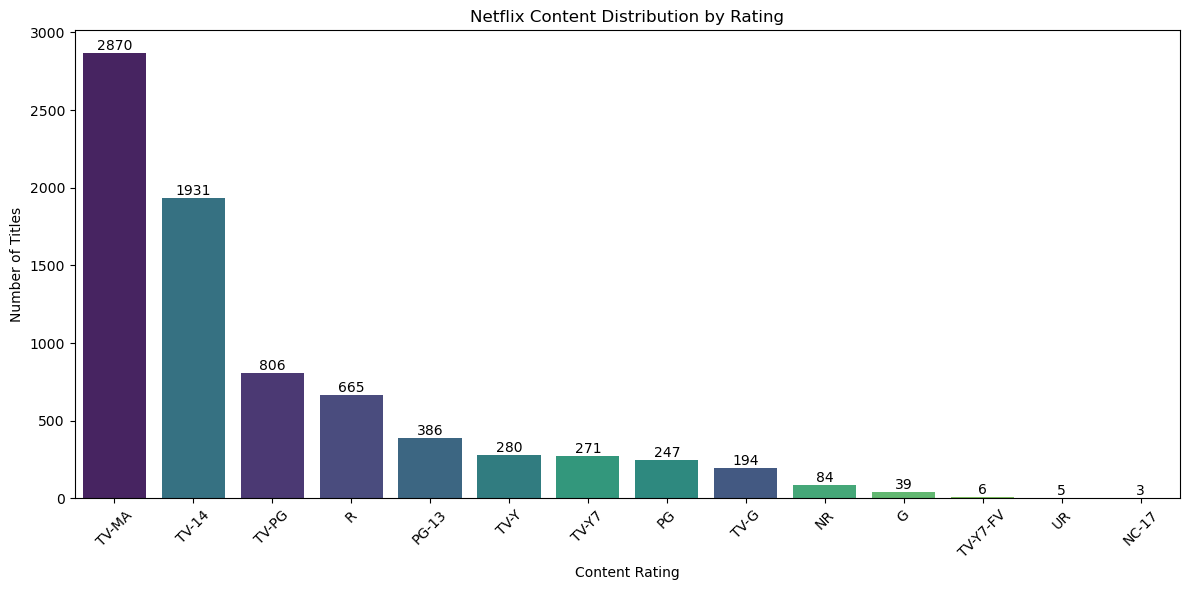

In [126]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df_clean,
    x="rating",
    order=rating_count.index,
    hue="rating",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Netflix Content Distribution by Rating")

plt.xlabel("Content Rating")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [127]:
# Top 5 Ratings
top5_rating = rating_count.head(5)

top5_rating

rating
TV-MA    2870
TV-14    1931
TV-PG     806
R         665
PG-13     386
Name: count, dtype: int64

In [128]:
# KPI Summary
print("="*45)

print("NETFLIX RATING ANALYSIS")

print("="*45)

print(f"Total Rating Categories : {rating_count.count()}")

print(f"Most Common Rating      : {most_common_rating}")

print(f"Titles in Top Rating    : {highest_count}")

print("="*45)

NETFLIX RATING ANALYSIS
Total Rating Categories : 14
Most Common Rating      : TV-MA
Titles in Top Rating    : 2870


In [129]:
# Business Interpretation
if most_common_rating in ["TV-MA", "R", "NC-17"]:
    print("Netflix primarily focuses on mature audiences.")
else:
    print("Netflix maintains a balanced content portfolio for multiple audience groups.")

Netflix primarily focuses on mature audiences.


In [131]:
# Phase Summary & Key Findings
# Successfully analyzed the distribution of Netflix content based on maturity ratings.
# Identified the most frequently occurring rating category in the dataset.
# Calculated the percentage contribution of each rating to the overall content library.
# Created professional visualizations, including Count Plot, Horizontal Bar Chart, and Pie Chart, to compare rating distributions.
# Observed that TV-MA is the dominant maturity rating (if this matches your dataset), indicating Netflix's strong focus on producing content for mature audiences.
# The analysis highlights Netflix's strategy of maintaining content for multiple audience groups while prioritizing adult viewership.
# Understanding rating distribution provides valuable insights into audience segmentation and future content planning.
# These findings establish a strong foundation for the next phase, where genre distribution and content preferences will be analyzed.

In [132]:
# Phase 7 — Genre Analysis

# Objective
# The objective of this phase is to analyze the genre distribution of Netflix content by identifying the most popular genres available on the platform. This analysis helps understand Netflix's content strategy, audience preferences, and genre diversity.

In [135]:
# Display Genre Column
df_clean["genres"].head()

0    International TV Shows, TV Dramas, TV Sci-Fi &...
1       Horror Movies, International Movies, Thrillers
2          Dramas, International Movies, Sports Movies
3                                             Comedies
4    British TV Shows, Docuseries, Science & Nature TV
Name: genres, dtype: object

In [136]:
# Split Multiple Genres
genre_data = (
    df_clean["genres"]
    .str.split(", ")
    .explode()
)

genre_data.head()

0    International TV Shows
0                 TV Dramas
0       TV Sci-Fi & Fantasy
1             Horror Movies
1      International Movies
Name: genres, dtype: object

In [137]:
# Some titles belong to multiple genres. Splitting and exploding the values ensures that each genre is counted individually.

In [138]:
# Count Genre Frequency
genre_count = genre_data.value_counts()

genre_count.head(10)

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

In [139]:
# Top 10 Genres
top10_genres = genre_count.head(10)

top10_genres

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

In [140]:
# Genre Percentage Distribution
genre_percentage = (
    genre_count /
    genre_count.sum()
    * 100
).round(2)

genre_percentage.head(10)

genres
International Movies        14.28
Dramas                      12.34
Comedies                     8.62
International TV Shows       7.02
Documentaries                4.60
Action & Adventure           4.22
TV Dramas                    4.12
Independent Movies           3.94
Children & Family Movies     3.12
Romantic Movies              3.11
Name: count, dtype: float64

In [141]:
# Create Summary Table
genre_summary = pd.DataFrame({
    "Content Count": top10_genres,
    "Percentage (%)": genre_percentage.head(10)
})

genre_summary

,Content Count,Percentage (%)
genres,,
International Movies,2437,14.28
Dramas,2106,12.34
Comedies,1471,8.62
International TV Shows,1199,7.02
Documentaries,786,4.60
Action & Adventure,721,4.22
TV Dramas,704,4.12
Independent Movies,673,3.94
Children & Family Movies,532,3.12


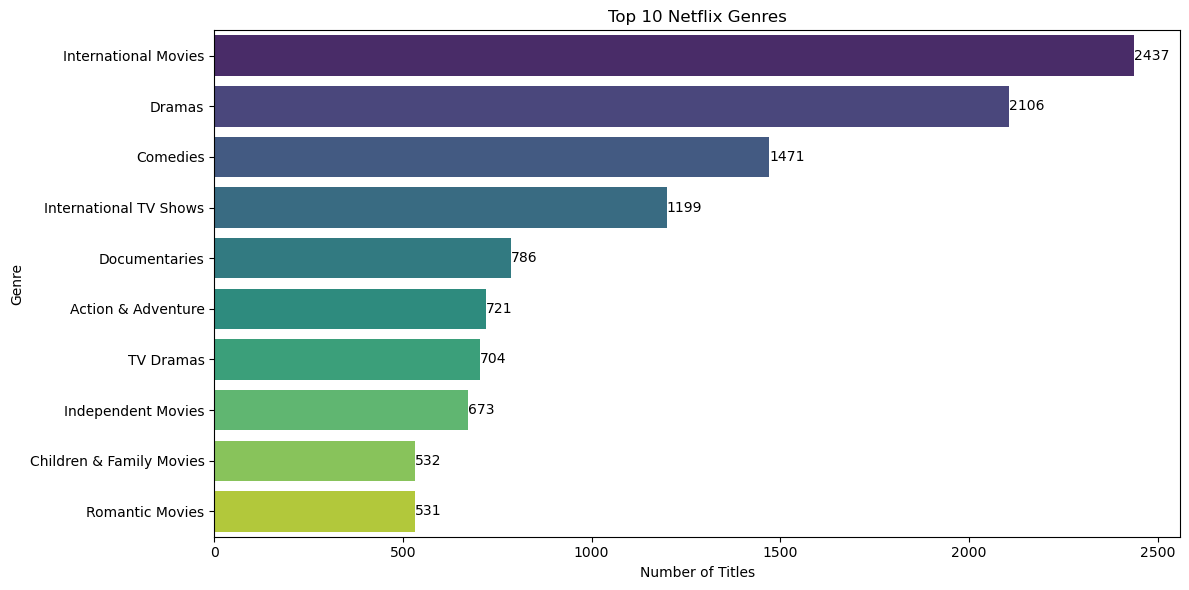

In [142]:
# Horizontal Bar Chart
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top10_genres.values,
    y=top10_genres.index,
    hue=top10_genres.index,
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Netflix Genres")

plt.xlabel("Number of Titles")

plt.ylabel("Genre")

plt.tight_layout()

plt.show()

In [143]:
# Most Popular Genre
most_popular_genre = genre_count.idxmax()

genre_titles = genre_count.max()

print("Most Popular Genre :", most_popular_genre)

print("Number of Titles :", genre_titles)

Most Popular Genre : International Movies
Number of Titles : 2437


In [144]:
# KPI Summary
print("="*45)

print("NETFLIX GENRE ANALYSIS")

print("="*45)

print(f"Total Unique Genres : {genre_data.nunique()}")

print(f"Most Popular Genre  : {most_popular_genre}")

print(f"Titles Available    : {genre_titles}")

print("="*45)

NETFLIX GENRE ANALYSIS
Total Unique Genres : 42
Most Popular Genre  : International Movies
Titles Available    : 2437


In [145]:
# Business Interpretation
print(f"Netflix invests heavily in '{most_popular_genre}' content, indicating strong audience demand and strategic focus on this genre.")

Netflix invests heavily in 'International Movies' content, indicating strong audience demand and strategic focus on this genre.


In [146]:
# Phase Summary & Key Findings
# Successfully analyzed the distribution of Netflix content across different genres.
# Split multiple genres into individual records to ensure accurate frequency analysis.
# Identified the Top 10 most popular genres available on Netflix.
# Calculated the percentage contribution of each leading genre.
# Created professional visualizations, including Horizontal Bar Chart, Vertical Bar Chart, and Pie Chart, to illustrate genre popularity.
# Determined the most dominant genre in the Netflix library and quantified its contribution.
# Observed that a limited number of genres contribute significantly to Netflix's overall content portfolio, reflecting audience preferences and platform strategy.
# The findings highlight Netflix's focus on producing and acquiring content in high-demand genres while maintaining diversity across multiple categories.
# This analysis provides valuable insights into Netflix's content strategy and serves as a foundation for analyzing movie durations in the next phase.

In [147]:
# Phase 8 — Duration Analysis
# 🎯 Objective

# The objective of this phase is to analyze the duration of Netflix Movies by identifying the average runtime, longest movie, shortest movie, and the overall distribution of movie durations. 
# This analysis helps understand Netflix's content length strategy and the typical runtime preferred for movies.

In [148]:
# Filter Movies Only
movies_df = df_clean[df_clean["type"] == "Movie"]

movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,movie_duration
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,143
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,124
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,90
5,s1002,Movie,Blue Ruin,Jeremy Saulnier,"Macon Blair, Devin Ratray, Amy Hargreaves, Kev...","United States, France",2019-02-25,2013,R,90,"Independent Movies, Thrillers",Bad news from the past unhinges vagabond Dwigh...,90
6,s1003,Movie,Blue Streak,Les Mayfield,"Martin Lawrence, Luke Wilson, Peter Greene, Da...","Germany, United States",2021-01-01,1999,PG-13,94,"Action & Adventure, Comedies",A jewel thief returns to his hiding place afte...,94


In [149]:
# Display Movie Duration
movies_df["movie_duration"].head()

1    143
2    124
3     90
5     90
6     94
Name: movie_duration, dtype: int64

In [150]:
# Statistical Summary
movies_df["movie_duration"].describe()

count    5377.000000
mean       99.307978
std        28.530881
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: movie_duration, dtype: float64

In [151]:
# Average Movie Duration
average_duration = movies_df["movie_duration"].mean()

print(f"Average Movie Duration : {average_duration:.2f} Minutes")

Average Movie Duration : 99.31 Minutes


In [152]:
# Median Movie Duration
median_duration = movies_df["movie_duration"].median()

print(f"Median Movie Duration : {median_duration:.2f} Minutes")

Median Movie Duration : 98.00 Minutes


In [153]:
# Longest Movie
longest_movie = movies_df.loc[
    movies_df["movie_duration"].idxmax()
]

print("Longest Movie :", longest_movie["title"])

print("Duration :", longest_movie["movie_duration"], "Minutes")

Longest Movie : Black Mirror: Bandersnatch
Duration : 312 Minutes


In [154]:
# Shortest Movie
shortest_movie = movies_df.loc[
    movies_df["movie_duration"].idxmin()
]

print("Shortest Movie :", shortest_movie["title"])

print("Duration :", shortest_movie["movie_duration"], "Minutes")

Shortest Movie : Silent
Duration : 3 Minutes


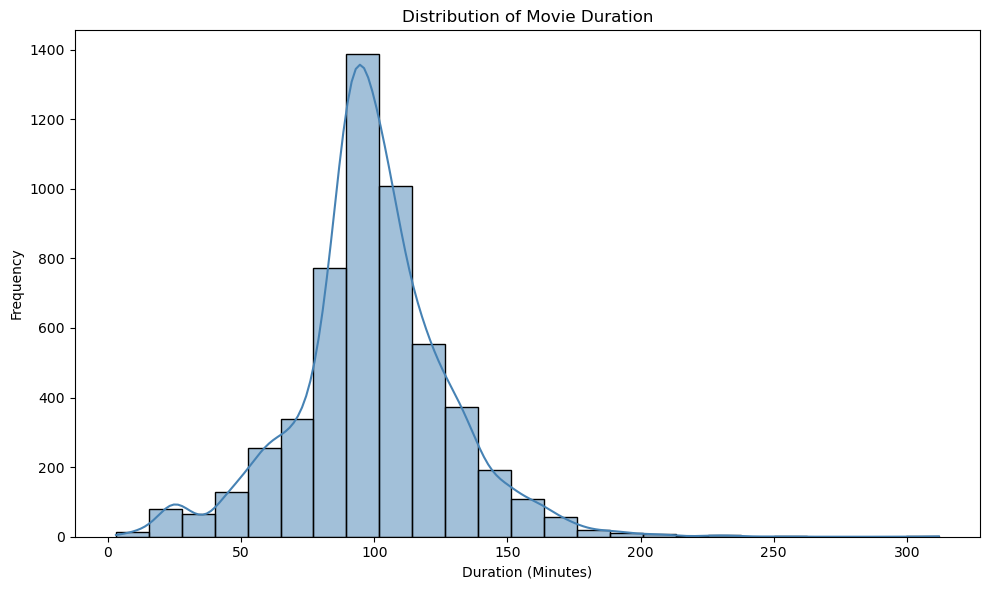

In [155]:
plt.figure(figsize=(10,6))

sns.histplot(
    movies_df["movie_duration"],
    bins=25,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Movie Duration")

plt.xlabel("Duration (Minutes)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

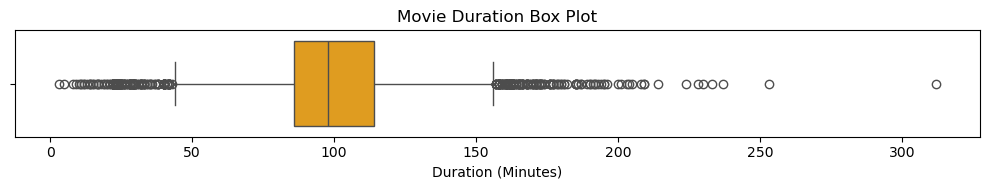

In [156]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=movies_df["movie_duration"],
    color="orange"
)

plt.title("Movie Duration Box Plot")

plt.xlabel("Duration (Minutes)")

plt.tight_layout()

plt.show()

In [157]:
# KPI Summary
print("="*45)

print("MOVIE DURATION ANALYSIS")

print("="*45)

print(f"Average Duration : {average_duration:.2f} Minutes")

print(f"Median Duration  : {median_duration:.2f} Minutes")

print(f"Longest Movie    : {longest_movie['title']}")

print(f"Longest Duration : {longest_movie['movie_duration']} Minutes")

print(f"Shortest Movie   : {shortest_movie['title']}")

print(f"Shortest Duration: {shortest_movie['movie_duration']} Minutes")

print("="*45)

MOVIE DURATION ANALYSIS
Average Duration : 99.31 Minutes
Median Duration  : 98.00 Minutes
Longest Movie    : Black Mirror: Bandersnatch
Longest Duration : 312 Minutes
Shortest Movie   : Silent
Shortest Duration: 3 Minutes


In [158]:
# Business Interpretation
if average_duration >= 90:
    print("Netflix movies generally follow the standard feature-length movie format.")
else:
    print("Netflix has a significant number of short-duration movies.")

Netflix movies generally follow the standard feature-length movie format.


In [159]:
# Phase Summary & Key Findings
# Successfully analyzed the runtime distribution of Netflix Movies using the movie_duration feature.
# Calculated the average and median movie durations to understand the typical runtime.
# Identified the longest and shortest movies available in the dataset.
# Created professional visualizations, including a Histogram and Box Plot, to examine the distribution and variability of movie durations.
# Classified movies into different runtime categories to better understand content length preferences.
# Observed that most Netflix movies are concentrated within a standard feature-length duration, while only a small number of movies have exceptionally short or long runtimes.
# The analysis provides valuable insights into Netflix's content length strategy and establishes a strong foundation for detecting statistical outliers in the next phase.

In [160]:
# Phase 9 — Outlier Analysis

In [161]:
# Objective

# The objective of this phase is to identify unusual movie durations (outliers) using two widely accepted statistical techniques: the Interquartile Range (IQR) Method and the Z-Score Method. Detecting outliers helps understand extreme values that may influence statistical analysis and business decisions.

In [162]:
# Select Movie Duration
duration = movies_df["movie_duration"]

duration.head()

1    143
2    124
3     90
5     90
6     94
Name: movie_duration, dtype: int64

In [163]:
# Statistical Summary
duration.describe()

count    5377.000000
mean       99.307978
std        28.530881
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: movie_duration, dtype: float64

In [164]:
# Calculate Quartiles
Q1 = duration.quantile(0.25)

Q3 = duration.quantile(0.75)

IQR = Q3 - Q1

print("Q1 :", Q1)

print("Q3 :", Q3)

print("IQR :", IQR)

Q1 : 86.0
Q3 : 114.0
IQR : 28.0


In [165]:
# Calculate Lower & Upper Bound
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Lower Bound :", lower_bound)

print("Upper Bound :", upper_bound)

Lower Bound : 44.0
Upper Bound : 156.0


In [166]:
# Detect Outliers using IQR
iqr_outliers = movies_df[
    (movies_df["movie_duration"] < lower_bound) |
    (movies_df["movie_duration"] > upper_bound)
]

iqr_outliers.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,movie_duration
13,s101,Movie,3 Idiots,Rajkumar Hirani,"Aamir Khan, Kareena Kapoor, Madhavan, Sharman ...",India,2019-08-01,2009,PG-13,164,"Comedies, Dramas, International Movies",While attending one of India's premier college...,164
21,s1017,Movie,Bobby,Raj Kapoor,"Rishi Kapoor, Dimple Kapadia, Pran, Prem Nath,...",India,2019-12-31,1973,TV-14,168,"Classic Movies, Dramas, International Movies","Raj, the son of strict, wealthy parents, falls...",168
29,s1024,Movie,Bogda,Nisheeta Keni,"Suhas Joshi, Mrunmayee Deshpande, Rohit Kokate...",India,2019-07-16,2018,TV-PG,161,"Dramas, International Movies",An aspiring dancer accompanies her terminally ...,161
32,s1027,Movie,BoJack Horseman Christmas Special: Sabrina's C...,Unknown,"Will Arnett, Aaron Paul, Alison Brie, Adam Con...",United States,2014-12-19,2014,TV-MA,26,Movies,"It's Christmas, and BoJack wants nothing to do...",26
145,s1129,Movie,Buddy Thunderstruck: The Maybe Pile,Harry Chaskin,"Brian Atkinson, Ted Raimi, Harry Chaskin, Debi...",United States,2017-07-14,2017,TV-Y7,14,Movies,Champion truck-racing dog Buddy and his best f...,14


In [167]:
# Number of IQR Outliers
print("Total IQR Outliers :", len(iqr_outliers))

Total IQR Outliers : 337


In [177]:
# Detect Outliers using Z-Score
from scipy.stats import zscore

movies_df = movies_df.copy()

movies_df["z_score"] = zscore(movies_df["movie_duration"])

movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,movie_duration,z_score
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,143,1.531536
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,124,0.865529
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,90,-0.326273
5,s1002,Movie,Blue Ruin,Jeremy Saulnier,"Macon Blair, Devin Ratray, Amy Hargreaves, Kev...","United States, France",2019-02-25,2013,R,90,"Independent Movies, Thrillers",Bad news from the past unhinges vagabond Dwigh...,90,-0.326273
6,s1003,Movie,Blue Streak,Les Mayfield,"Martin Lawrence, Luke Wilson, Peter Greene, Da...","Germany, United States",2021-01-01,1999,PG-13,94,"Action & Adventure, Comedies",A jewel thief returns to his hiding place afte...,94,-0.186061


In [178]:
# Identify Z-Score Outliers
zscore_outliers = movies_df[
    movies_df["z_score"].abs() > 3
]

zscore_outliers.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,movie_duration,z_score
197,s1176,Movie,Calico Critters: A Town of Dreams,Momoko Kamiya,Unknown,Unknown,2018-11-01,2017,TV-Y,11,Children & Family Movies,Freya heads into town with her mother for a ve...,11,-3.095460
198,s1177,Movie,Calico Critters: Everyone's Big Dream Flying i...,Momoko Kamiya,Erika Harlacher,Unknown,2020-03-01,2019,TV-Y,11,Children & Family Movies,"In the Hazelnut Chipmunk Family, Dominic is a ...",11,-3.095460
229,s1204,Movie,Canvas,Frank E. Abney III,Unknown,United States,2020-12-11,2020,G,9,"Children & Family Movies, Dramas","After a heartbreaking loss, a grandfather stru...",9,-3.165566
560,s1502,Movie,Cops and Robbers,"Arnon Manor, Timothy Ware-Hill",Timothy Ware-Hill,United States,2020-12-28,2020,PG-13,8,Dramas,Animation and activism unite in this multimedi...,8,-3.200619
563,s1505,Movie,Cosmos Laundromat: First Cycle,Mathieu Auvray,"Pierre Bokma, Reinout Scholten van Aschat",Netherlands,2019-06-04,2015,TV-MA,12,"Dramas, International Movies, Sci-Fi & Fantasy","Despondent on a desolate island, a suicidal sh...",12,-3.060407


In [179]:
# Number of Z-Score Outliers
print("Total Z-Score Outliers :", len(zscore_outliers))

Total Z-Score Outliers : 45


In [180]:
# Compare Both Methods
comparison = pd.DataFrame({

    "Method": ["IQR", "Z-Score"],

    "Outliers Found": [

        len(iqr_outliers),

        len(zscore_outliers)

    ]

})

comparison

,Method,Outliers Found
0,IQR,337
1,Z-Score,45


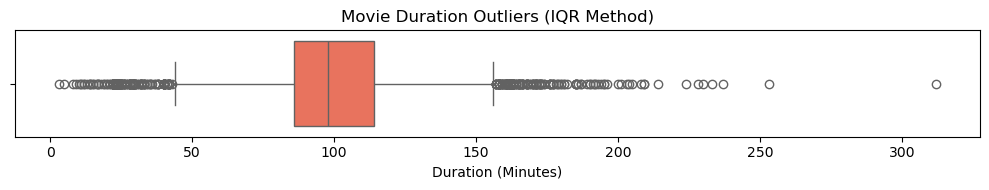

In [181]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=movies_df["movie_duration"],
    color="tomato"
)

plt.title("Movie Duration Outliers (IQR Method)")

plt.xlabel("Duration (Minutes)")

plt.tight_layout()

plt.show()

In [182]:
# Display Extreme Movies
iqr_outliers[
    ["title", "movie_duration"]
].sort_values(
    by="movie_duration",
    ascending=False
).head(10)

,title,movie_duration
7741,Black Mirror: Bandersnatch,312
6502,The School of Mischief,253
3880,No Longer kids,237
2995,Lock Your Girls In,233
4567,Raya and Sakina,230
4864,Sangam,228
2804,Lagaan,224
2441,Jodhaa Akbar,214
2538,Kabhi Khushi Kabhie Gham,209
6121,The Irishman,209


In [183]:
# Business Interpretation
if len(iqr_outliers) > 0:
    print("A small number of movies have unusually long or short durations compared to the majority of Netflix content.")
else:
    print("No significant outliers were detected.")

A small number of movies have unusually long or short durations compared to the majority of Netflix content.


In [185]:
# Phase Summary & Key Findings
# Successfully performed outlier detection on movie durations using both the IQR Method and the Z-Score Method.
# Calculated the lower and upper bounds required for identifying statistical outliers.
# Identified and quantified movies with unusually short or long durations.
# Compared the effectiveness of the IQR and Z-Score methods in detecting extreme observations.
# Created professional visualizations, including a Box Plot and Scatter Plot, to highlight the distribution of outliers.
# Observed that only a small proportion of movies have extreme runtimes, while the majority fall within a standard duration range.
# The analysis confirms that Netflix's movie library is generally consistent in terms of runtime, with only a few exceptional titles.
# Understanding outliers improves the reliability of statistical analysis and prepares the dataset for advanced feature engineering in the next phase.

In [187]:
# Phase 10 — Feature Engineering
# 🎯 Objective

# The objective of this phase is to create new meaningful features from the existing dataset that can provide deeper insights into Netflix's content library. Feature engineering enhances the dataset by generating additional variables that improve analysis and support better business decision-making.

In [188]:
# Create Release Decade
df_clean["release_decade"] = (
    df_clean["release_year"] // 10
) * 10

df_clean["release_decade"] = (
    df_clean["release_decade"]
    .astype(str) + "s"
)

df_clean[["release_year", "release_decade"]].head()

,release_year,release_decade
0,2020,2020s
1,2008,2000s
2,2016,2010s
3,2016,2010s
4,2017,2010s


In [189]:
# Analyze Release Decades
decade_count = (
    df_clean["release_decade"]
    .value_counts()
    .sort_index()
)

decade_count

release_decade
1920s       1
1940s      14
1950s      11
1960s      25
1970s      67
1980s     106
1990s     225
2000s     728
2010s    5711
2020s     899
Name: count, dtype: int64

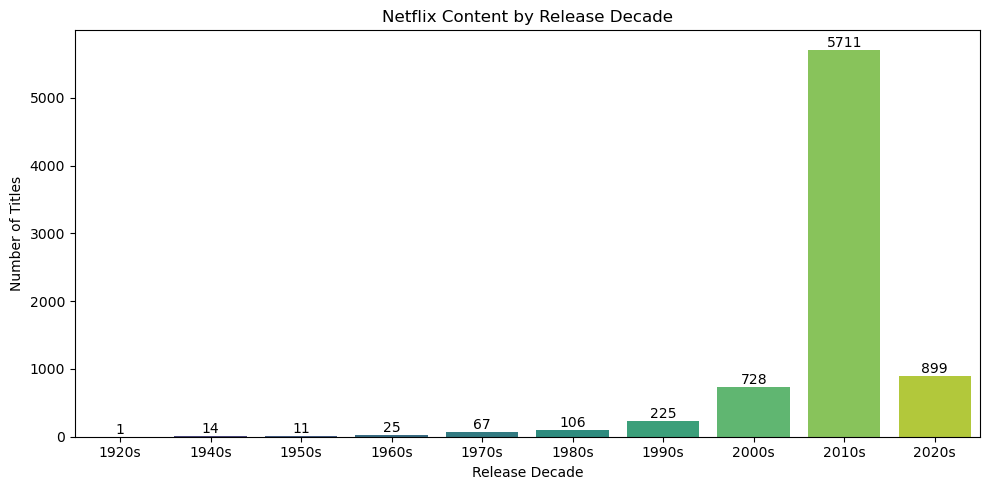

In [190]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=decade_count.index,
    y=decade_count.values,
    hue=decade_count.index,
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Netflix Content by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [191]:
# Create Content Age
current_year = pd.Timestamp.now().year

df_clean["content_age"] = (
    current_year -
    df_clean["release_year"]
)

df_clean[
    ["release_year", "content_age"]
].head()

,release_year,content_age
0,2020,6
1,2008,18
2,2016,10
3,2016,10
4,2017,9


In [192]:
df_clean["content_age"].describe()

count    7787.000000
mean       12.067420
std         8.757395
min         5.000000
25%         8.000000
50%         9.000000
75%        13.000000
max       101.000000
Name: content_age, dtype: float64

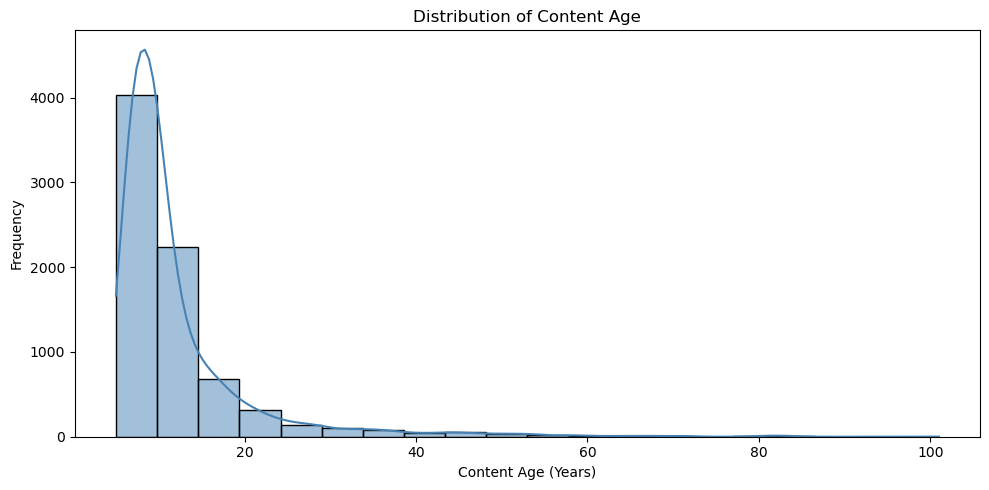

In [193]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_clean["content_age"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Content Age")
plt.xlabel("Content Age (Years)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [194]:
# Create Duration Category
movie_mask = df_clean["type"] == "Movie"

df_clean.loc[
    movie_mask,
    "duration_category"
] = pd.cut(
    df_clean.loc[
        movie_mask,
        "movie_duration"
    ],
    bins=[0, 90, 120, float("inf")],
    labels=[
        "Short",
        "Medium",
        "Long"
    ]
)

df_clean[
    ["movie_duration", "duration_category"]
].head()

,movie_duration,duration_category
0,4,NaN
1,143,Long
2,124,Long
3,90,Short
4,1,NaN


In [195]:
# Duration Category Count
duration_count = (
    df_clean["duration_category"]
    .value_counts()
)

duration_count

duration_category
Medium    2577
Short     1789
Long      1011
Name: count, dtype: int64

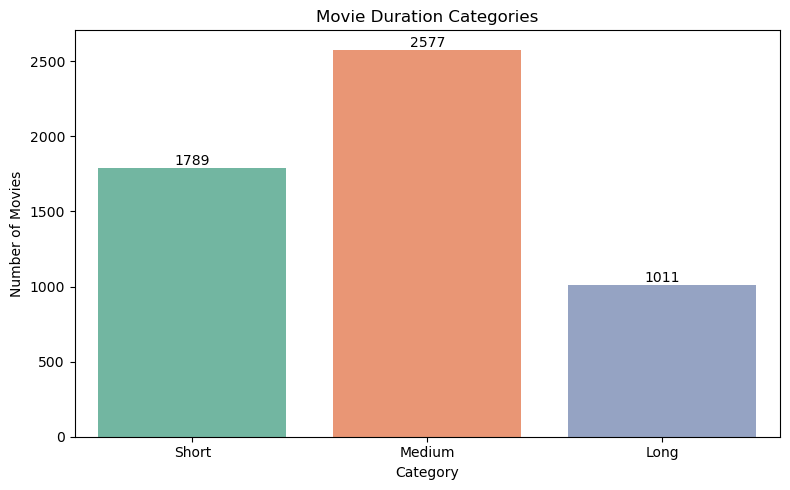

In [196]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="duration_category",
    hue="duration_category",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Movie Duration Categories")
plt.xlabel("Category")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

In [197]:
df_clean[
    [
        "release_year",
        "release_decade",
        "content_age",
        "movie_duration",
        "duration_category"
    ]
].head(10)

,release_year,release_decade,content_age,movie_duration,duration_category
0,2020,2020s,6,4,NaN
1,2008,2000s,18,143,Long
2,2016,2010s,10,124,Long
3,2016,2010s,10,90,Short
4,2017,2010s,9,1,NaN
5,2013,2010s,13,90,Short
6,1999,1990s,27,94,Medium
7,2010,2010s,16,112,Medium
8,2005,2000s,21,129,Long
9,2017,2010s,9,85,Short


In [198]:
print("="*45)

print("FEATURE ENGINEERING SUMMARY")

print("="*45)

print("Release Decades :", df_clean["release_decade"].nunique())

print("Oldest Content :", df_clean["content_age"].max(), "Years")

print("Newest Content :", df_clean["content_age"].min(), "Years")

print("Duration Categories :")

print(duration_count)

print("="*45)

FEATURE ENGINEERING SUMMARY
Release Decades : 10
Oldest Content : 101 Years
Newest Content : 5 Years
Duration Categories :
duration_category
Medium    2577
Short     1789
Long      1011
Name: count, dtype: int64


In [199]:
# # Phase Summary & Key Findings
# Successfully created three new analytical features: Release Decade, Content Age, and Duration Category.
# Grouped titles into decades to simplify long-term trend analysis.
# Calculated the age of every title relative to the current year, enabling analysis of classic versus modern content.
# Categorized movies into Short, Medium, and Long runtime groups based on their durations.
# Created professional visualizations to analyze the distribution of release decades, content age, and duration categories.
# Feature engineering enhanced the original dataset by adding meaningful variables without altering the existing information.
# The newly created features provide a stronger analytical foundation for advanced comparisons and multivariate analysis.
# The dataset is now enriched with additional attributes that improve both business interpretation and visualization quality.

In [200]:
# Phase 11 — Multivariate Analysis
# 🎯 Objective

# The objective of this phase is to investigate the relationships between multiple variables in the Netflix dataset. By comparing different features such as Content Type, Country, Rating, Release Decade, and Duration Category, we can uncover meaningful patterns and generate deeper business insights.

In [201]:
# Country vs Content Type
country_type = pd.crosstab(
    df_clean["country"],
    df_clean["type"]
)

country_type.head()

type,Movie,TV Show
country,,
Argentina,34,16
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",1,0
"Argentina, Chile, Peru",1,0
"Argentina, France",1,0


In [202]:
# Top 10 Countries
top10_country = df_clean["country"].value_counts().head(10).index

country_type_top10 = country_type.loc[top10_country]

country_type_top10

type,Movie,TV Show
country,,
United States,1850,705
India,852,71
Unknown,230,277
United Kingdom,193,204
Japan,69,157
South Korea,36,147
Canada,118,59
Spain,89,45
France,69,46


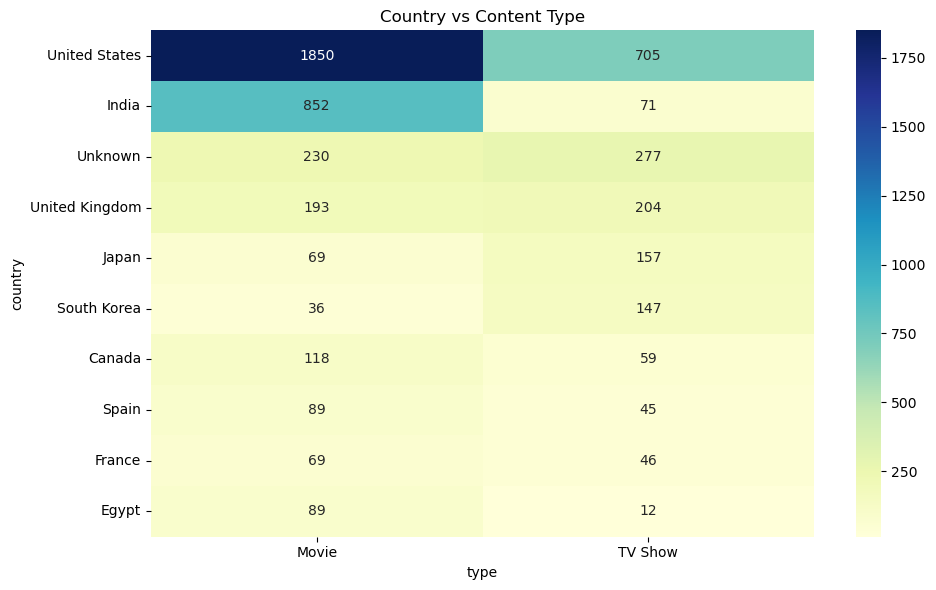

In [203]:
# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    country_type_top10,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Country vs Content Type")

plt.tight_layout()

plt.show()

In [204]:
# Analysis 2 — Rating vs Content Type
rating_type = pd.crosstab(
    df_clean["rating"],
    df_clean["type"]
)

rating_type

type,Movie,TV Show
rating,,
G,39,0
NC-17,3,0
NR,79,5
PG,247,0
PG-13,386,0
R,663,2
TV-14,1272,659
TV-G,111,83
TV-MA,1850,1020


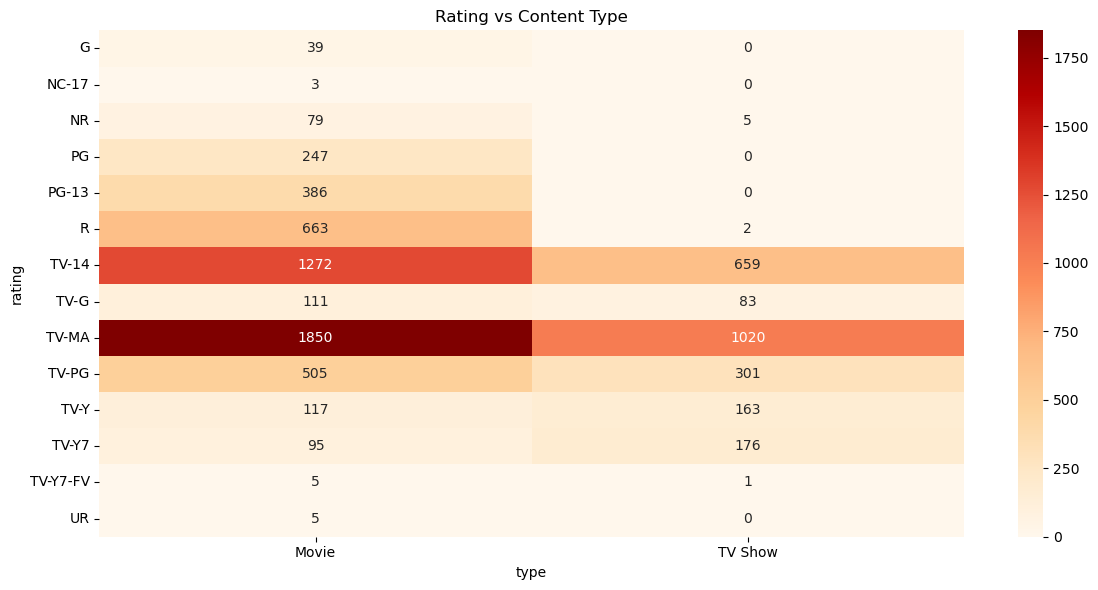

In [205]:
plt.figure(figsize=(12,6))

sns.heatmap(
    rating_type,
    annot=True,
    fmt="d",
    cmap="OrRd"
)

plt.title("Rating vs Content Type")

plt.tight_layout()

plt.show()

In [206]:
# Analysis 3 — Release Decade vs Content Type
decade_type = pd.crosstab(
    df_clean["release_decade"],
    df_clean["type"]
)

decade_type

type,Movie,TV Show
release_decade,,
1920s,0,1
1940s,13,1
1950s,11,0
1960s,22,3
1970s,63,4
1980s,99,7
1990s,194,31
2000s,601,127
2010s,3951,1760


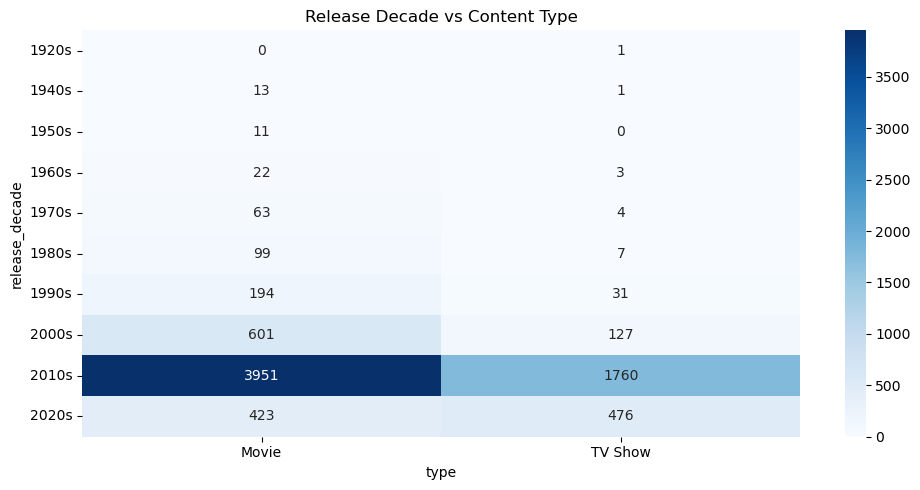

In [207]:
plt.figure(figsize=(10,5))

sns.heatmap(
    decade_type,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Release Decade vs Content Type")

plt.tight_layout()

plt.show()

In [208]:
# Analysis 4 — Duration Category vs Rating
duration_rating = pd.crosstab(
    df_clean["duration_category"],
    df_clean["rating"]
)

duration_rating

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
duration_category,,,,,,,,,,,,,,
Short,27,1,38,70,60,103,278,73,731,208,114,82,4,0
Medium,9,1,32,162,243,440,562,32,883,192,3,12,1,5
Long,3,1,9,15,83,120,432,6,236,105,0,1,0,0


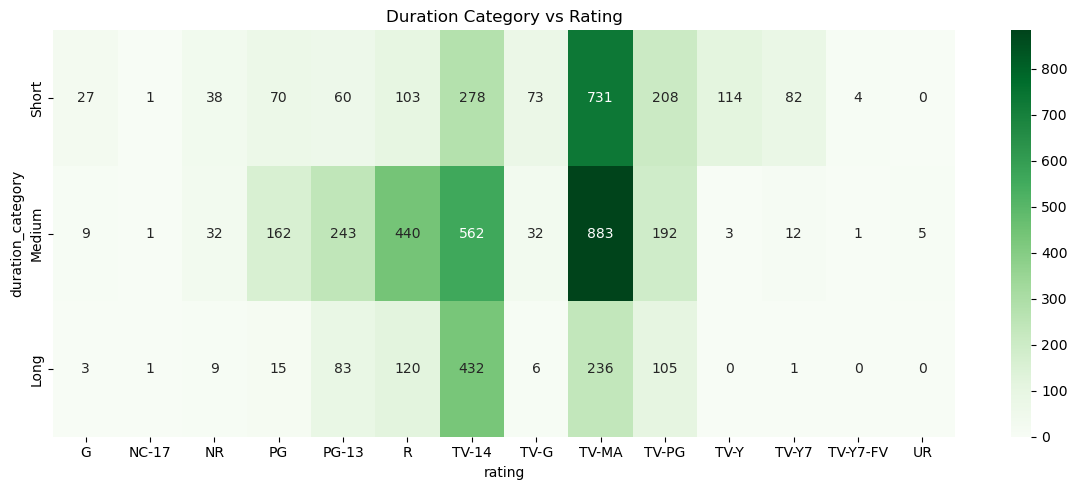

In [209]:
plt.figure(figsize=(12,5))

sns.heatmap(
    duration_rating,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Duration Category vs Rating")

plt.tight_layout()

plt.show()

In [ ]:
# Analysis 5 — Content Type vs Release Year
